In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
aqi_data = pd.read_csv("delhi_aqi_dataset.csv")

In [2]:
aqi_data.describe()

,year,month,day,hour,is_weekend,latitude,longitude,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi
count,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000
mean,2022.499544,6.521898,15.732664,14.750000,0.285584,28.596791,77.208600,183.420341,348.567402,69.761495,16.028998,3.033964,27.185762,26.895227,61.041564,10.528524,5.007801,265.830148
std,1.708185,3.448995,8.801392,6.378691,0.451693,0.112215,0.125113,193.138161,370.016790,75.972086,17.201027,3.284094,13.569802,8.984843,24.737106,6.045043,3.685609,171.508950
min,2020.000000,1.000000,1.000000,6.000000,0.000000,28.372200,77.026600,15.000000,24.000000,8.000000,4.000000,0.300000,12.000000,6.000000,20.000000,2.100000,0.200000,25.000000
25%,2021.000000,4.000000,8.000000,10.500000,0.000000,28.530800,77.071200,55.300000,104.100000,19.900000,4.500000,0.870000,18.000000,19.900000,39.000000,5.900000,1.900000,103.000000
50%,2022.500000,7.000000,16.000000,15.000000,0.000000,28.624600,77.201000,99.500000,189.800000,38.300000,8.700000,1.690000,23.300000,27.600000,58.000000,9.200000,4.400000,232.000000
75%,2024.000000,10.000000,23.000000,19.250000,1.000000,28.668300,77.316400,254.700000,481.200000,94.000000,20.900000,4.120000,31.800000,33.500000,83.000000,14.200000,7.100000,464.000000
max,2025.000000,12.000000,31.000000,23.000000,1.000000,28.776200,77.504000,900.000000,1979.700000,593.500000,121.600000,22.670000,84.000000,44.800000,100.000000,31.500000,15.000000,500.000000


In [3]:
aqi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201664 entries, 0 to 201663
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   datetime      201664 non-null  object 
 1   date          201664 non-null  object 
 2   year          201664 non-null  int64  
 3   month         201664 non-null  int64  
 4   day           201664 non-null  int64  
 5   hour          201664 non-null  int64  
 6   day_of_week   201664 non-null  object 
 7   is_weekend    201664 non-null  int64  
 8   season        201664 non-null  object 
 9   city          201664 non-null  object 
 10  station       201664 non-null  object 
 11  latitude      201664 non-null  float64
 12  longitude     201664 non-null  float64
 13  pm25          201664 non-null  float64
 14  pm10          201664 non-null  float64
 15  no2           201664 non-null  float64
 16  so2           201664 non-null  float64
 17  co            201664 non-null  float64
 18  o3  

In [4]:
df = aqi_data.drop(columns=['datetime', 'date', 'day_of_week', 'station', 'month', 'day'], axis = 1)

In [5]:
new_df = df.loc[aqi_data['city'] == 'Delhi', :].copy()

In [6]:
new_df = new_df.drop('city', axis = 1)

In [7]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122752 entries, 0 to 201627
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          122752 non-null  int64  
 1   hour          122752 non-null  int64  
 2   is_weekend    122752 non-null  int64  
 3   season        122752 non-null  object 
 4   latitude      122752 non-null  float64
 5   longitude     122752 non-null  float64
 6   pm25          122752 non-null  float64
 7   pm10          122752 non-null  float64
 8   no2           122752 non-null  float64
 9   so2           122752 non-null  float64
 10  co            122752 non-null  float64
 11  o3            122752 non-null  float64
 12  temperature   122752 non-null  float64
 13  humidity      122752 non-null  int64  
 14  wind_speed    122752 non-null  float64
 15  visibility    122752 non-null  float64
 16  aqi           122752 non-null  int64  
 17  aqi_category  122752 non-null  object 
dtypes: float6

In [8]:
df_encoded = pd.get_dummies(new_df, columns=['season'], drop_first=False)

In [9]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122752 entries, 0 to 201627
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 122752 non-null  int64  
 1   hour                 122752 non-null  int64  
 2   is_weekend           122752 non-null  int64  
 3   latitude             122752 non-null  float64
 4   longitude            122752 non-null  float64
 5   pm25                 122752 non-null  float64
 6   pm10                 122752 non-null  float64
 7   no2                  122752 non-null  float64
 8   so2                  122752 non-null  float64
 9   co                   122752 non-null  float64
 10  o3                   122752 non-null  float64
 11  temperature          122752 non-null  float64
 12  humidity             122752 non-null  int64  
 13  wind_speed           122752 non-null  float64
 14  visibility           122752 non-null  float64
 15  aqi                  1

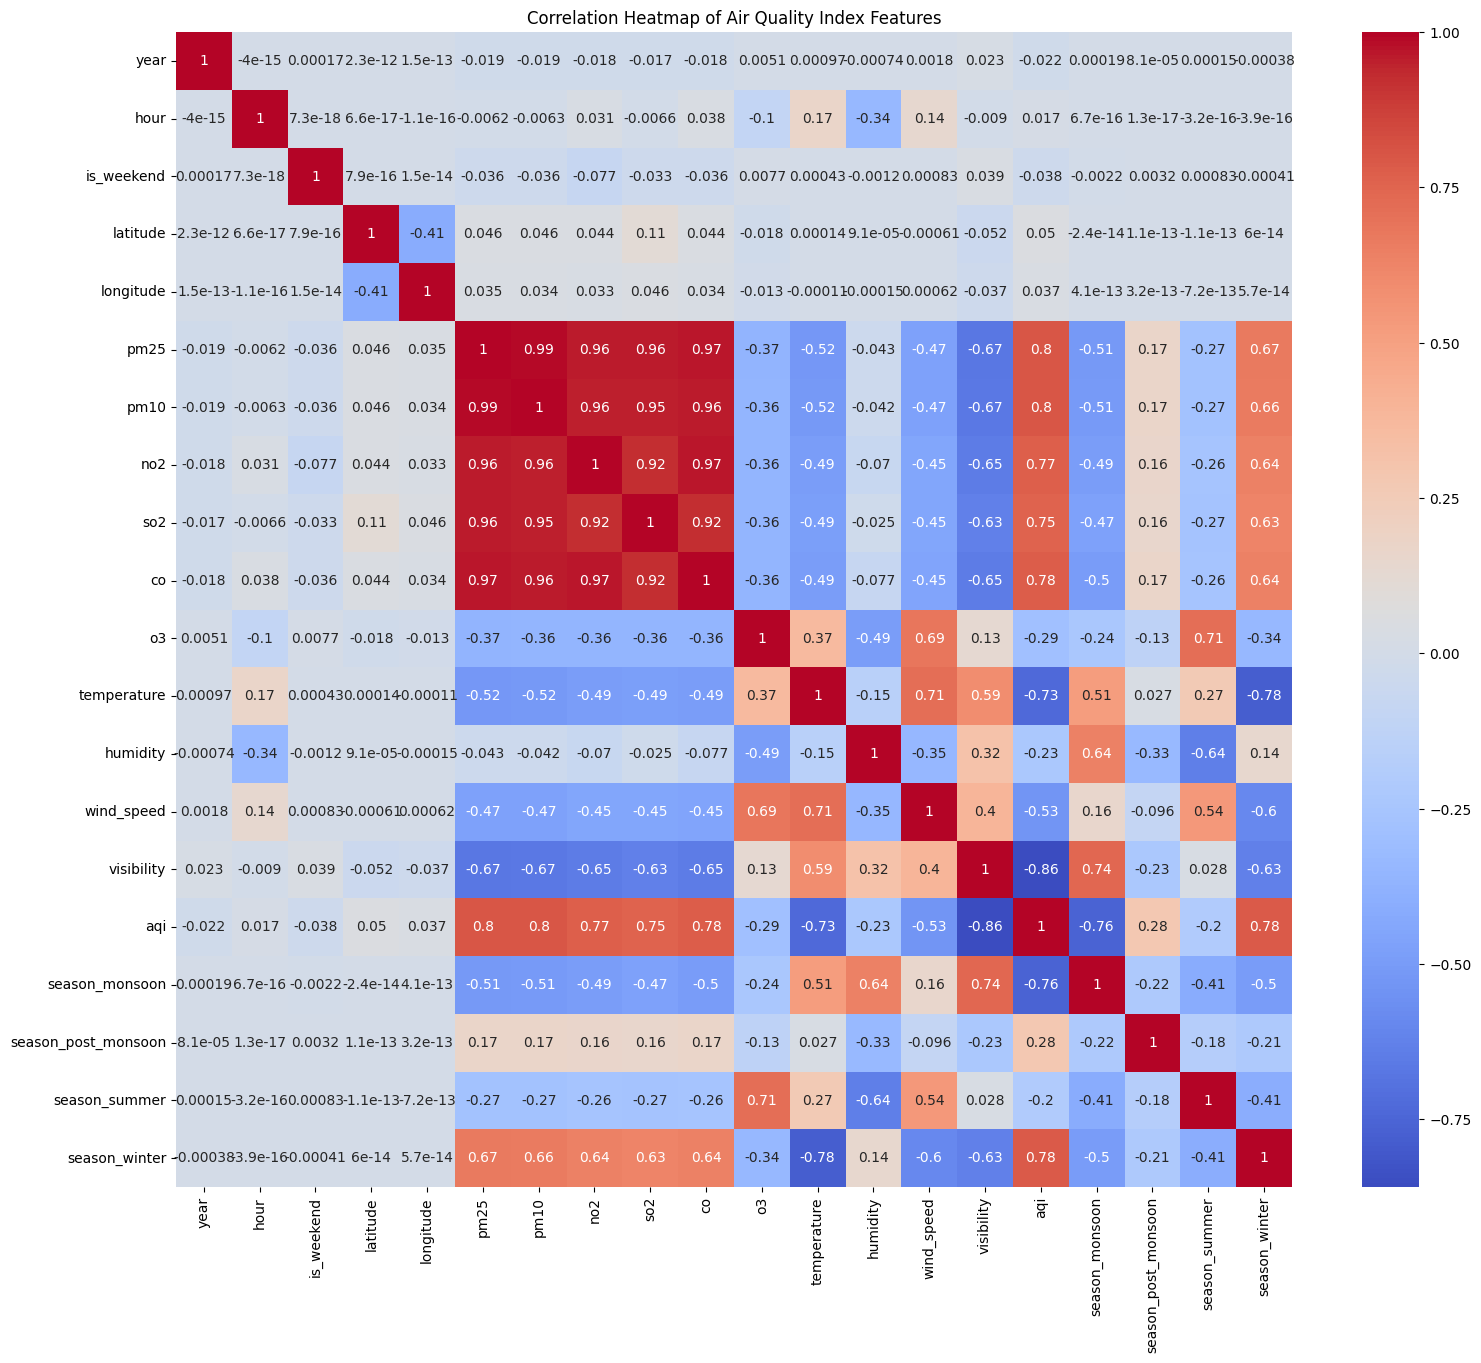

In [10]:
corr_matrix = df_encoded.drop('aqi_category', axis = 1).corr()
plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Air Quality Index Features')
plt.show()